In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
EDGE_FILE = "/content/drive/MyDrive/SN-HW2/Wiki-Vote.txt"

edges = []
with open(EDGE_FILE, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        u, v = line.strip().split()
        edges.append((int(u), int(v)))

G = nx.DiGraph()
G.add_edges_from(edges)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 7115
Edges: 103689



Top-10 Authority (saved: a_top10_authority.csv)


,node,authority_score,rank_authority
905,2398,0.002580,1
326,4037,0.002573,2
2,3352,0.002328,3
286,1549,0.002304,4
432,762,0.002256,5
1005,3089,0.002253,6
247,1297,0.002250,7
699,2565,0.002224,8
409,15,0.002202,9
711,2625,0.002198,10



Top-10 PageRank (saved: a_top10_pagerank.csv)


,node,pagerank_score,rank_pagerank
326,4037,0.004613,1
409,15,0.003681,2
1332,6634,0.003525,3
711,2625,0.003286,4
905,2398,0.002605,5
686,2470,0.002530,6
656,2237,0.002505,7
1141,4191,0.002266,8
1261,7553,0.002170,9
3,5254,0.002150,10


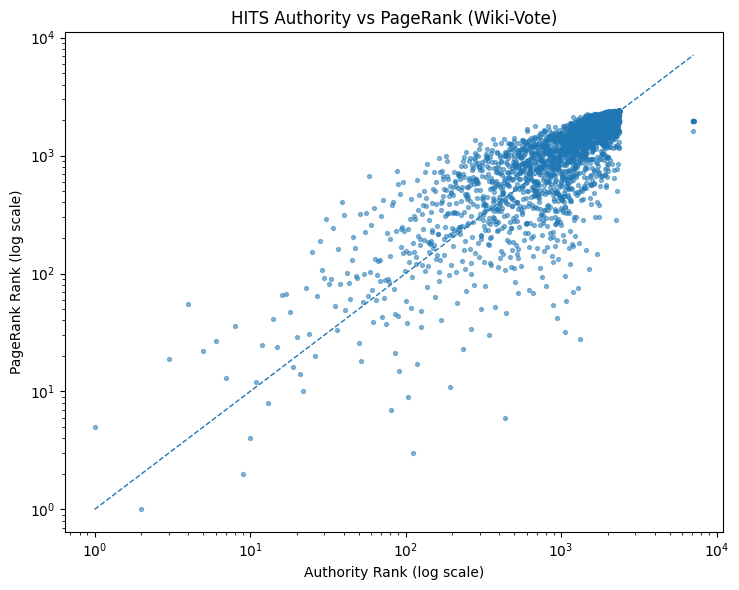

In [6]:
hubs, authorities = nx.hits(G, max_iter=1000, normalized=True)

auth_df = pd.DataFrame({
    "node": authorities.keys(),
    "authority_score": authorities.values()
})

auth_df["rank_authority"] = auth_df["authority_score"].rank(
    ascending=False, method="min"
).astype(int)


pagerank = nx.pagerank(G, alpha=0.85)

pr_df = pd.DataFrame({
    "node": pagerank.keys(),
    "pagerank_score": pagerank.values()
})

pr_df["rank_pagerank"] = pr_df["pagerank_score"].rank(
    ascending=False, method="min"
).astype(int)


merged = auth_df.merge(pr_df, on="node", how="inner")


OUT_DIR = "/content/drive/MyDrive/SN-HW2/"
os.makedirs(OUT_DIR, exist_ok=True)

top10_auth = merged.sort_values("rank_authority").head(10)[
    ["node", "authority_score", "rank_authority"]
]
top10_pr = merged.sort_values("rank_pagerank").head(10)[
    ["node", "pagerank_score", "rank_pagerank"]
]

top10_auth.to_csv(os.path.join(OUT_DIR, "a_top10_authority.csv"), index=False)
top10_pr.to_csv(os.path.join(OUT_DIR, "a_top10_pagerank.csv"), index=False)

print("\nTop-10 Authority (saved: a_top10_authority.csv)")
display(top10_auth)

print("\nTop-10 PageRank (saved: a_top10_pagerank.csv)")
display(top10_pr)


plt.figure(figsize=(7.5, 6))
plt.scatter(
    merged["rank_authority"],
    merged["rank_pagerank"],
    s=8,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Authority Rank (log scale)")
plt.ylabel("PageRank Rank (log scale)")
plt.title("HITS Authority vs PageRank (Wiki-Vote)")

max_rank = max(merged["rank_authority"].max(), merged["rank_pagerank"].max())
plt.plot([1, max_rank], [1, max_rank], linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()